In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# ============================================================
# 1. USTAWIENIA
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)

SEQ_LEN = 60
N_FEATURES = 3
N_NORMAL = 2000
N_ANOM = 300


In [3]:
# ============================================================
# 2. GENEROWANIE NORMALNYCH SEKWENCJI
# ============================================================

def generate_normal_sequence(seq_len=60):
    t = np.linspace(0, 4 * np.pi, seq_len)

    f1 = np.sin(t) + np.random.normal(0, 0.08, seq_len)
    f2 = 0.6 * np.cos(t * 0.8) + np.random.normal(0, 0.08, seq_len)
    f3 = 0.3 * np.sin(t * 1.5 + 0.5) + np.random.normal(0, 0.05, seq_len)

    seq = np.stack([f1, f2, f3], axis=1)
    return seq

In [4]:
def generate_anomalous_sequence(seq_len=60):
    seq = generate_normal_sequence(seq_len).copy()

    anomaly_type = np.random.choice(["spike", "drift", "oscillation"])
    start = np.random.randint(20, 40)

    if anomaly_type == "spike":
        seq[start:start+5, 0] += np.random.uniform(2.5, 4.0)

    elif anomaly_type == "drift":
        seq[start:, 1] += np.linspace(0, 3.0, seq_len - start)

    elif anomaly_type == "oscillation":
        seq[start:start+15, 2] += 1.5 * np.sin(np.linspace(0, 8*np.pi, min(15, seq_len-start)))

    return seq

In [5]:
X_normal = np.array([generate_normal_sequence(SEQ_LEN) for _ in range(N_NORMAL)])
X_anom = np.array([generate_anomalous_sequence(SEQ_LEN) for _ in range(N_ANOM)])

y_normal = np.zeros(N_NORMAL, dtype=int)
y_anom = np.ones(N_ANOM, dtype=int)


In [6]:
# ============================================================
# 3. PODZIAŁ I SKALOWANIE
# ============================================================

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

X_test = np.concatenate([X_normal[:300], X_anom], axis=0)
y_test = np.concatenate([np.zeros(300, dtype=int), np.ones(N_ANOM, dtype=int)], axis=0)

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, N_FEATURES)
X_val_2d = X_val.reshape(-1, N_FEATURES)
X_test_2d = X_test.reshape(-1, N_FEATURES)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

In [7]:
# ============================================================
# 4. LSTM AUTOENCODER
# ============================================================

inputs = layers.Input(shape=(SEQ_LEN, N_FEATURES))

x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(32, return_sequences=False)(x)

latent = layers.Dense(16, activation="relu", name="latent_vector")(x)

x = layers.RepeatVector(SEQ_LEN)(latent)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.LSTM(64, return_sequences=True)(x)

outputs = layers.TimeDistributed(layers.Dense(N_FEATURES))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 3)          │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,651 (240.82 KB)

 Trainable params: 61,651 (240.82 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ============================================================
# 5. TRENING
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=60,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)



Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - loss: 0.9050 - val_loss: 0.2270
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 0.1321 - val_loss: 0.0530
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - loss: 0.0512 - val_loss: 0.0450
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - loss: 0.0446 - val_loss: 0.0427
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - loss: 0.0415 - val_loss: 0.0392
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - loss: 0.0395 - val_loss: 0.0387
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - loss: 0.0385 - val_loss: 0.0376
Epoch 8/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0376 - val_loss: 0.0373
Epoch 9/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step - loss: 0.0371 - val_loss: 0.0367
Epoch 10/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - loss: 0.0366 - val_loss: 0.0364
Epoch 11/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 0.0362 - val_loss: 0.0361
Epoch 12/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 134m

In [9]:
# ============================================================
# 6. REKONSTRUKCJA I BŁĄD
# ============================================================

X_test_recon = model.predict(X_test_scaled, verbose=0)

# błąd na sekwencję
seq_mse = np.mean((X_test_scaled - X_test_recon) ** 2, axis=(1, 2))

# próg z walidacji
X_val_recon = model.predict(X_val_scaled, verbose=0)
val_mse = np.mean((X_val_scaled - X_val_recon) ** 2, axis=(1, 2))
threshold = np.percentile(val_mse, 95)

y_pred = (seq_mse > threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", np.mean(y_pred == y_test))



Threshold: 0.041964412786228006
Accuracy: 0.99


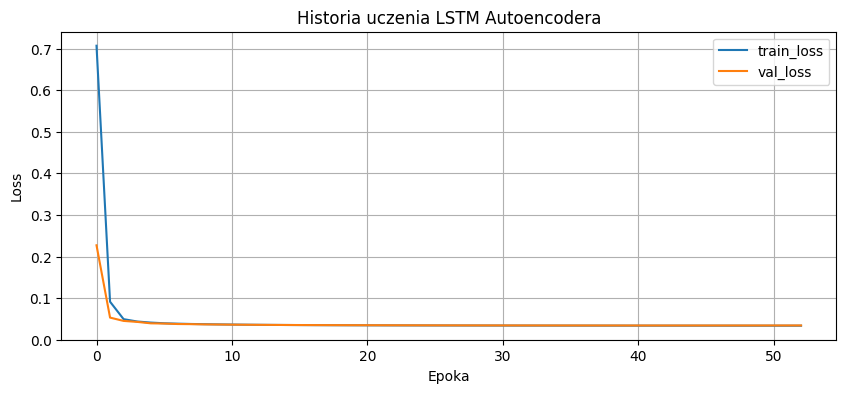

In [10]:
# ============================================================
# 7. WYKRES HISTORII UCZENIA
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Historia uczenia LSTM Autoencodera")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



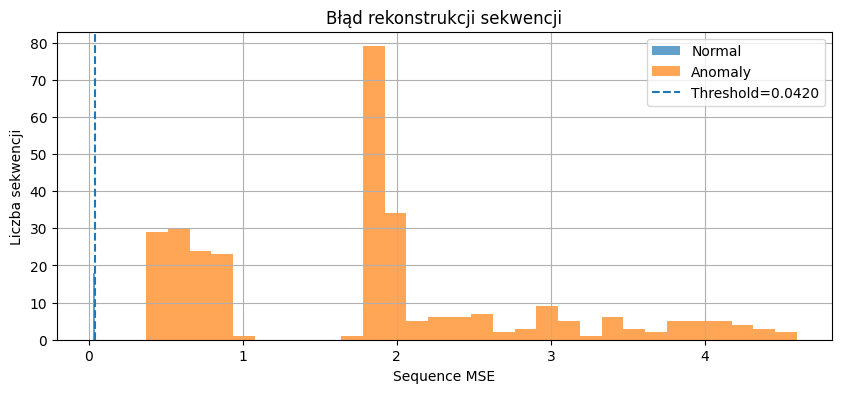

In [11]:
# ============================================================
# 8. WYKRES BŁĘDU REKONSTRUKCJI
# ============================================================

plt.figure(figsize=(10, 4))
plt.hist(seq_mse[y_test == 0], bins=30, alpha=0.7, label="Normal")
plt.hist(seq_mse[y_test == 1], bins=30, alpha=0.7, label="Anomaly")
plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.4f}")
plt.title("Błąd rekonstrukcji sekwencji")
plt.xlabel("Sequence MSE")
plt.ylabel("Liczba sekwencji")
plt.legend()
plt.grid(True)
plt.show()


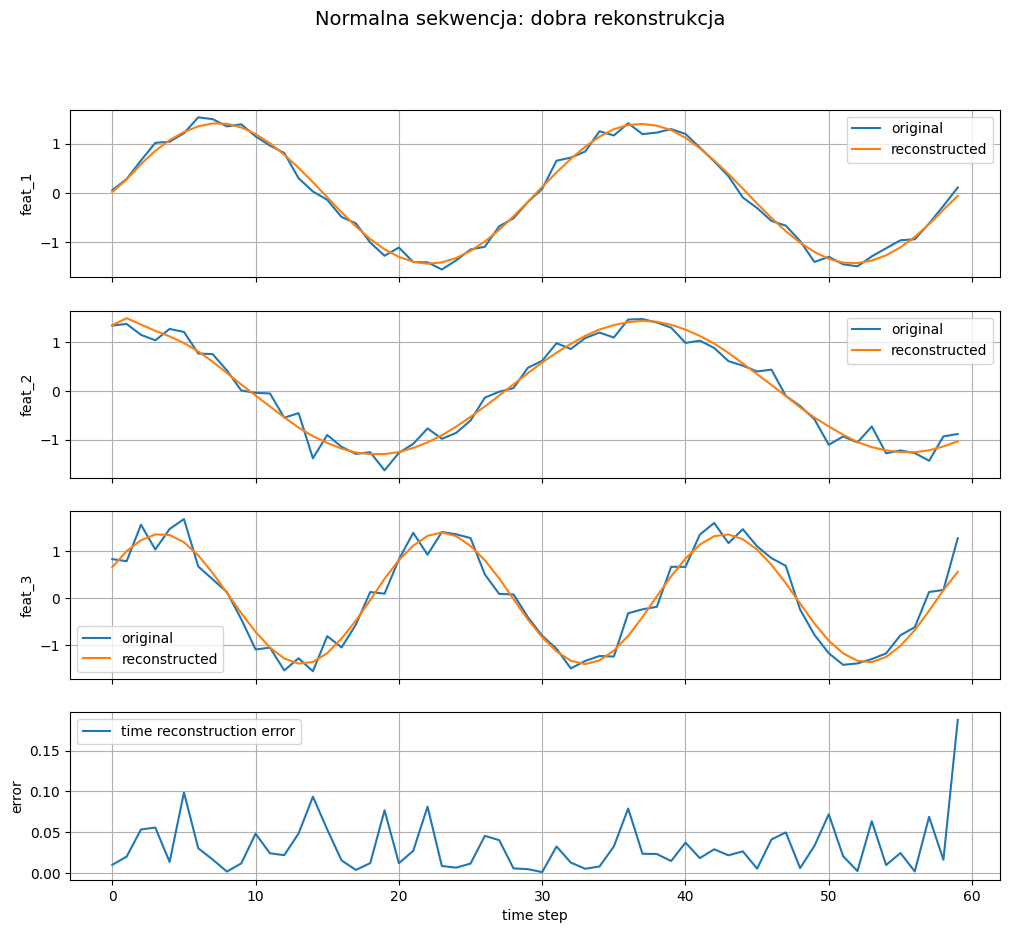

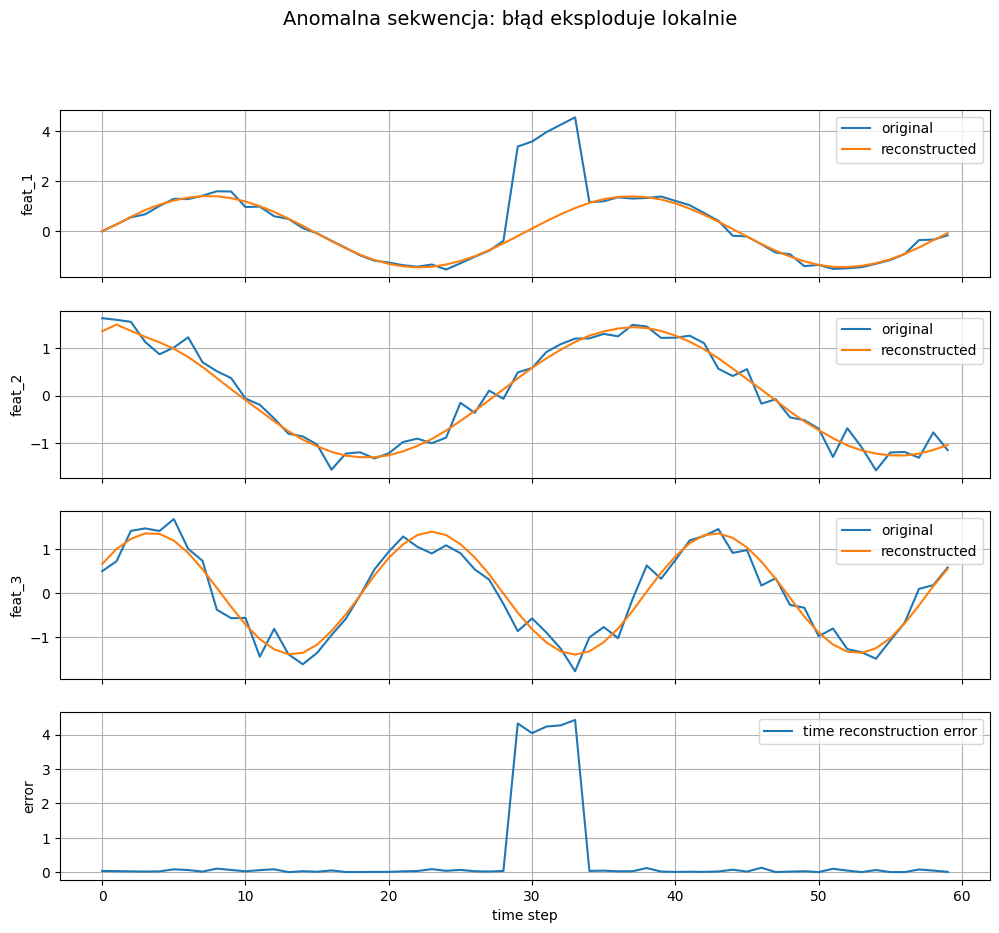

In [12]:
# ============================================================
# 9. EFEKT WOW: JEDNA NORMALNA I JEDNA ANOMALNA SEKWENCJA
# ============================================================

normal_idx = np.where(y_test == 0)[0][0]
anom_idx = np.where(y_test == 1)[0][0]

def plot_sequence_comparison(idx, title):
    original = X_test_scaled[idx]
    reconstructed = X_test_recon[idx]
    error_t = np.mean((original - reconstructed) ** 2, axis=1)

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    for f in range(N_FEATURES):
        axes[f].plot(original[:, f], label="original")
        axes[f].plot(reconstructed[:, f], label="reconstructed")
        axes[f].set_ylabel(f"feat_{f+1}")
        axes[f].legend()
        axes[f].grid(True)

    axes[3].plot(error_t, label="time reconstruction error")
    axes[3].set_ylabel("error")
    axes[3].set_xlabel("time step")
    axes[3].legend()
    axes[3].grid(True)

    fig.suptitle(title, fontsize=14)
    plt.show()


plot_sequence_comparison(normal_idx, "Normalna sekwencja: dobra rekonstrukcja")
plot_sequence_comparison(anom_idx, "Anomalna sekwencja: błąd eksploduje lokalnie")